# 🌲📈 Gradient Boosting Classifier

## 📌 ¿Qué es Gradient Boosting?
**Gradient Boosting** es un método de *ensembling* que combina muchos modelos débiles (generalmente árboles de decisión pequeños) para formar un modelo fuerte.  
Se basa en construir los árboles **secuencialmente**, donde cada nuevo árbol intenta corregir los errores del anterior.

Es uno de los algoritmos más poderosos para clasificación y regresión.

---

## 📌 Idea principal
Gradient Boosting funciona así:

1. Entrena un modelo inicial (por ejemplo, un árbol muy simple).
2. Calcula los **errores o residuos** de ese modelo.
3. Entrena un nuevo árbol para corregir esos errores.
4. Repite el proceso muchas veces.
5. Suma todos los árboles para crear la predicción final.

Cada árbol aporta una pequeña corrección → *boosting*.

---

## 📌 ¿Por qué “Gradient”?
Se llama **Gradient** porque optimiza una función de pérdida  
(minimiza el error) usando **descenso del gradiente**, pero aplicada a modelos.

Acumula árboles que se mueven en la dirección del gradiente negativo  
(es decir, corrigen el error actual).


## 📌 Resumen en una frase
**Gradient Boosting construye muchos árboles pequeños, cada uno corrigiendo los errores del anterior, y los combina para formar un modelo muy preciso.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('titanic').dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:
cols = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
X = df[cols]
y = df[target]

In [ ]:
X = pd.get_dummies(X,columns=['sex','embarked'],drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# APLICAMOS EL ALGORITMO DE GRADIENT BOOSTING

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,# nro de árboles
    learning_rate=0.1,# taza de aprendizaje
    max_depth=3, #profundidad maxima de cada árbol
    random_state=42
)

In [ ]:
gb_model.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = gb_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Precisión del modelo: {accuracy}')

Precisión del modelo: 0.7567567567567568


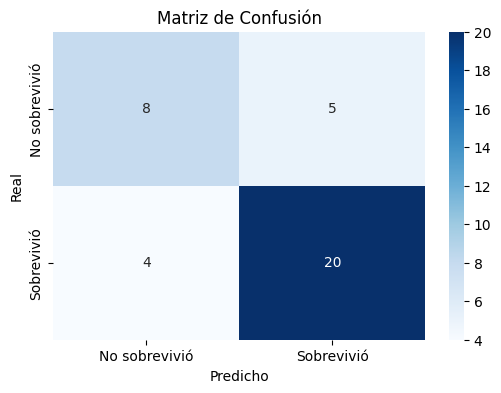

In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()